In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import string
from collections import Counter
sns.set(style="whitegrid")

In [3]:
nltk.download("punkt")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to C:\Users\Aarushi
[nltk_data]     Sachdeva\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to C:\Users\Aarushi
[nltk_data]     Sachdeva\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [4]:
jigsaw_train = pd.read_csv("../data/raw/jigsaw/train.csv")
hate_speech = pd.read_csv("../data/raw/hate_speech/labeled_data.csv")
goemotions = pd.read_csv("../data/raw/goemotions/go_emotions_dataset.csv")

In [5]:
print(jigsaw_train.shape)
print(hate_speech.shape)
print(goemotions.shape)

(159571, 8)
(24783, 7)
(211225, 31)


In [6]:
print(jigsaw_train.columns,"\n")
print(hate_speech.columns,"\n")
print(goemotions.columns)

Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='object') 

Index(['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither',
       'class', 'tweet'],
      dtype='object') 

Index(['id', 'text', 'example_very_unclear', 'admiration', 'amusement',
       'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity',
       'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment',
       'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
       'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse',
       'sadness', 'surprise', 'neutral'],
      dtype='object')


In [7]:
print("Jigsaw")
display(jigsaw_train.head())
print("\nHate speech")
display(hate_speech.head())
print("\nGoEmotions")
display(goemotions.head())

Jigsaw


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0



Hate speech


,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...



GoEmotions


,id,text,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,confusion,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,eew5j0j,That game hurt.,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,eemcysk,>sexuality shouldn’t be a grouping category I...,True,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ed2mah1,"You do right, if you don't care then fuck 'em!",False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,eeibobj,Man I love reddit.,False,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,eda6yn6,"[NAME] was nowhere near them, he was by the Fa...",False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [8]:
print("Missing values \nJigsaw dataset")
print(jigsaw_train.isnull().sum())

print("\nHate Speech dataset")
print(hate_speech.isnull().sum())

print("\nGoEmotions dataset")
print(goemotions.isnull().sum())

Missing values 
Jigsaw dataset
id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

Hate Speech dataset
Unnamed: 0            0
count                 0
hate_speech           0
offensive_language    0
neither               0
class                 0
tweet                 0
dtype: int64

GoEmotions dataset
id                      0
text                    0
example_very_unclear    0
admiration              0
amusement               0
anger                   0
annoyance               0
approval                0
caring                  0
confusion               0
curiosity               0
desire                  0
disappointment          0
disapproval             0
disgust                 0
embarrassment           0
excitement              0
fear                    0
gratitude               0
grief                   0
joy                     0
love                    0
nervousnes

In [9]:
print("text column\n Jigsaw dataset")
print(jigsaw_train["comment_text"].iloc[0])
print("\nHate speech")
print(hate_speech["tweet"].iloc[0])
print("\nGoEmotions")
print(goemotions["text"].iloc[0])

text column
 Jigsaw dataset
Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27

Hate speech
!!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always take the trash out...

GoEmotions
That game hurt.


In [10]:
toxicity_counts = jigsaw_train["toxic"].value_counts()
print("Jigsaw Toxic label distribution:")
print(toxicity_counts)

Jigsaw Toxic label distribution:
toxic
0    144277
1     15294
Name: count, dtype: int64


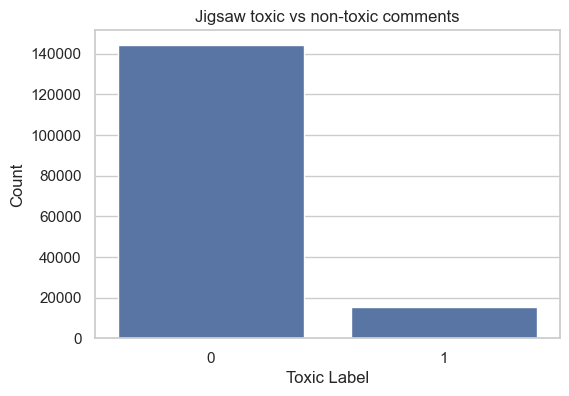

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x="toxic", data=jigsaw_train)
plt.title("Jigsaw toxic vs non-toxic comments")
plt.xlabel("Toxic Label")
plt.ylabel("Count")
plt.show()

In [12]:
hate_speech_counts = hate_speech["class"].value_counts()
print("Hate speech class distribution:")
print(hate_speech_counts)

Hate speech class distribution:
class
1    19190
2     4163
0     1430
Name: count, dtype: int64


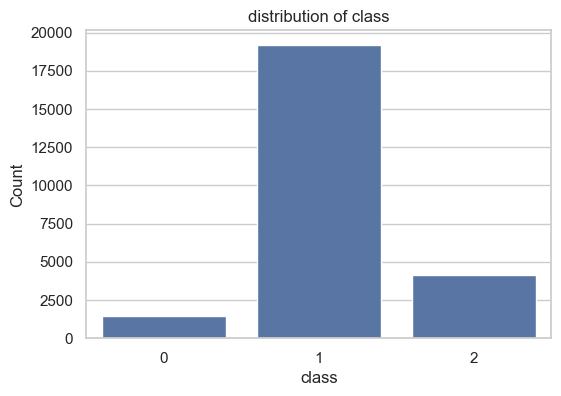

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x="class", data=hate_speech)
plt.title("distribution of class")
plt.xlabel("class")
plt.ylabel("Count")
plt.show()

In [17]:
emotion_columns = goemotions.columns[3:]
emotion_counts = goemotions[emotion_columns].sum().sort_values(ascending=False)
print("Top 15 emotions:")
print(emotion_counts.head(15))

Top 15 emotions:
neutral           55298
approval          17620
admiration        17131
annoyance         13618
gratitude         11625
disapproval       11424
curiosity          9692
amusement          9245
realization        8785
optimism           8715
disappointment     8469
love               8191
anger              8084
joy                7983
confusion          7359
dtype: int64


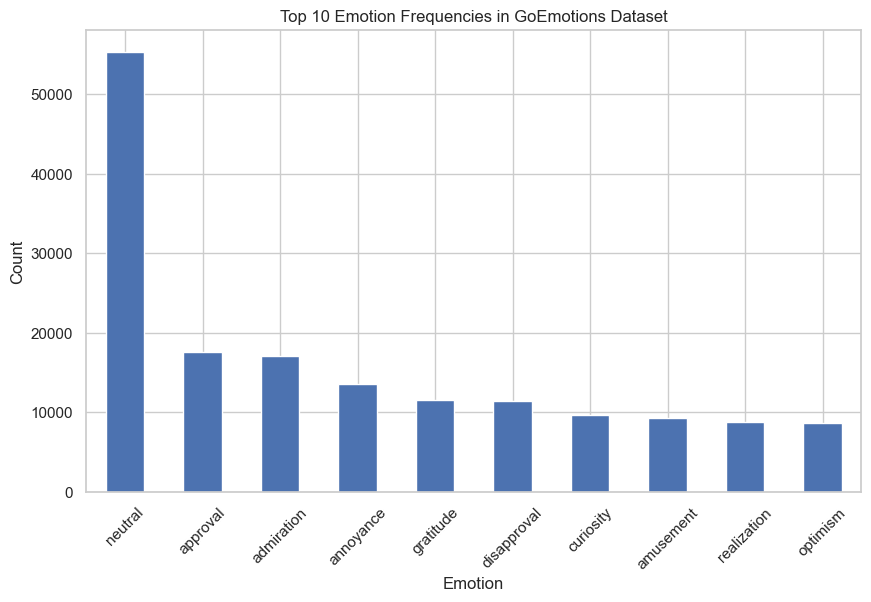

In [18]:
plt.figure(figsize=(10,6))
emotion_counts.head(10).plot(kind="bar")
plt.title("Top 10 Emotion Frequencies in GoEmotions Dataset")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

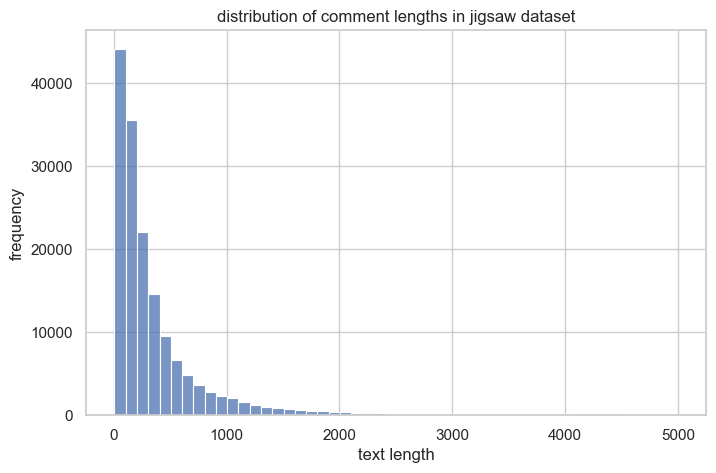

In [20]:
jigsaw_train["text_length"] = jigsaw_train["comment_text"].apply(len)
plt.figure(figsize=(8,5))
sns.histplot(jigsaw_train["text_length"], bins=50)
plt.title("distribution of comment lengths in jigsaw dataset")
plt.xlabel("text length")
plt.ylabel("frequency")
plt.show()

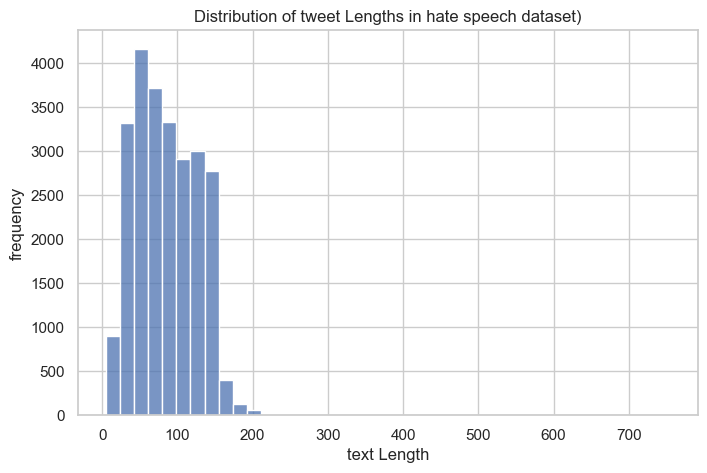

In [21]:
hate_speech["text_length"] = hate_speech["tweet"].apply(len)
plt.figure(figsize=(8,5))
sns.histplot(hate_speech["text_length"], bins=40)
plt.title("Distribution of tweet Lengths in hate speech dataset)")
plt.xlabel("text Length")
plt.ylabel("frequency")
plt.show()

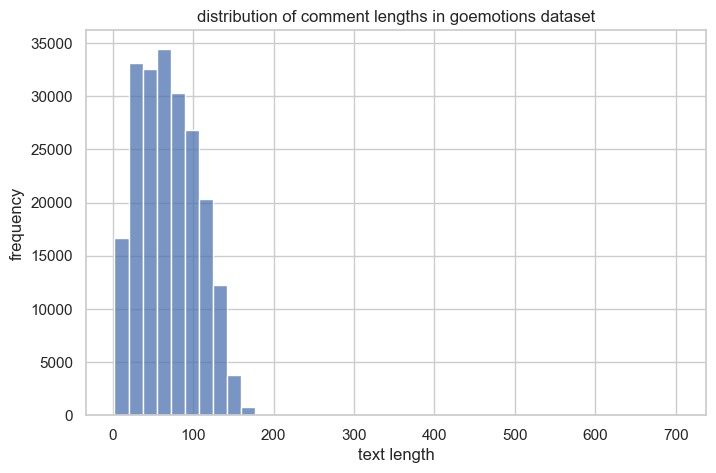

In [22]:
goemotions["text_length"] = goemotions["text"].apply(len)
plt.figure(figsize=(8,5))
sns.histplot(goemotions["text_length"], bins=40)
plt.title("distribution of comment lengths in goemotions dataset")
plt.xlabel("text length")
plt.ylabel("frequency")
plt.show()

In [71]:
jigsaw_standard = jigsaw_train.copy()
jigsaw_standard["label"] = jigsaw_standard[
    ["toxic","severe_toxic","obscene","threat","insult","identity_hate"]
].max(axis=1)
jigsaw_standard = jigsaw_standard[["comment_text","label"]]
jigsaw_standard.rename(columns={"comment_text":"text"}, inplace=True)
jigsaw_standard.head()

,text,label
0,Explanation\nWhy the edits made under my usern...,0
1,D'aww! He matches this background colour I'm s...,0
2,"Hey man, I'm really not trying to edit war. It...",0
3,"""\nMore\nI can't make any real suggestions on ...",0
4,"You, sir, are my hero. Any chance you remember...",0


In [72]:
hate_standard = hate_speech.copy()
hate_standard.rename(columns={"tweet":"text"}, inplace=True)
hate_standard = hate_standard[["text","class"]]
hate_standard.rename(columns={"class":"label"}, inplace=True)
hate_standard.head()

,text,label
0,!!! RT @mayasolovely: As a woman you shouldn't...,2
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,1
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,1
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,1
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,1


In [73]:
goemotion_standard = goemotions[(goemotions["neutral"]==1) | 
(goemotions["admiration"] == 1) | (goemotions["gratitude"] == 1)].copy()
goemotion_standard.head()


,id,text,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,confusion,...,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral,text_length
2,ed2mah1,"You do right, if you don't care then fuck 'em!",False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,46
4,eda6yn6,"[NAME] was nowhere near them, he was by the Fa...",False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,52
5,eespn2i,Right? Considering it’s such an important docu...,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,135
10,ed9w1hm,"I have, and now that you mention it, I think t...",False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,81
12,ef7tl7i,BUT IT'S HER TURN! /s,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,21


In [74]:
goemotion_standard = goemotion_standard[["text"]]
goemotion_standard["label"] = "neutral"
goemotion_standard.head()

,text,label
2,"You do right, if you don't care then fuck 'em!",neutral
4,"[NAME] was nowhere near them, he was by the Fa...",neutral
5,Right? Considering it’s such an important docu...,neutral
10,"I have, and now that you mention it, I think t...",neutral
12,BUT IT'S HER TURN! /s,neutral


In [75]:
print("Jigsaw standardized:")
print(jigsaw_standard.head())
print("\nHate speech standardized:")
print(hate_standard.head())
print("\nGoEmotions standardized:")
print(goemotion_standard.head())

Jigsaw standardized:
                                                text  label
0  Explanation\nWhy the edits made under my usern...      0
1  D'aww! He matches this background colour I'm s...      0
2  Hey man, I'm really not trying to edit war. It...      0
3  "\nMore\nI can't make any real suggestions on ...      0
4  You, sir, are my hero. Any chance you remember...      0

Hate speech standardized:
                                                text  label
0  !!! RT @mayasolovely: As a woman you shouldn't...      2
1  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...      1
2  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...      1
3  !!!!!!!!! RT @C_G_Anderson: @viva_based she lo...      1
4  !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...      1

GoEmotions standardized:
                                                 text    label
2      You do right, if you don't care then fuck 'em!  neutral
4   [NAME] was nowhere near them, he was by the Fa...  neutral
5   Right? Consid

In [76]:
jigsaw_standard["label"] = jigsaw_standard["label"].map({0: "neutral",1: "toxic"})
jigsaw_standard.head()

,text,label
0,Explanation\nWhy the edits made under my usern...,neutral
1,D'aww! He matches this background colour I'm s...,neutral
2,"Hey man, I'm really not trying to edit war. It...",neutral
3,"""\nMore\nI can't make any real suggestions on ...",neutral
4,"You, sir, are my hero. Any chance you remember...",neutral


In [77]:
hate_standard["label"] = hate_standard["label"].map({0: "toxic",1: "toxic",2: "neutral"})
hate_standard.head()

,text,label
0,!!! RT @mayasolovely: As a woman you shouldn't...,neutral
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,toxic
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,toxic
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,toxic
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,toxic


In [54]:
goemotion_standard.shape

(27591, 2)

In [78]:
merged_dataset = pd.concat([jigsaw_standard,hate_standard,goemotion_standard], ignore_index=True)
print(merged_dataset.shape)
merged_dataset.head()

(267243, 2)


,text,label
0,Explanation\nWhy the edits made under my usern...,neutral
1,D'aww! He matches this background colour I'm s...,neutral
2,"Hey man, I'm really not trying to edit war. It...",neutral
3,"""\nMore\nI can't make any real suggestions on ...",neutral
4,"You, sir, are my hero. Any chance you remember...",neutral


In [79]:
merged_dataset["label"].value_counts()

label
neutral    230398
toxic       36845
Name: count, dtype: int64

In [81]:
toxic_data = merged_dataset[merged_dataset["label"] == "toxic"]
neutral_data = merged_dataset[merged_dataset["label"] == "neutral"]

In [82]:
neutral_sampled = neutral_data.sample(
    n=len(toxic_data),
    random_state=42
)

In [83]:
balanced_dataset = pd.concat([toxic_data,neutral_sampled])
balanced_dataset = balanced_dataset.sample(frac=1, random_state=42)
balanced_dataset.reset_index(drop=True, inplace=True)

balanced_dataset["label"].value_counts()

label
neutral    36845
toxic      36845
Name: count, dtype: int64